In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy import stats as s
import Stat_record_dependecies as srd

In [7]:
offense = srd.offensive_data
defense = srd.defensive_data
offense.columns

Index(['Year', 'Team', 'W', 'L', 'T', 'PCT', 'SB Winner', 'Att', 'Cmp',
       'Cmp %', 'Yds/Att', 'Pass Yds', 'TD', 'INT', 'Rate', '1st', '1st%',
       '20+', '40+', 'Lng', 'Sck', 'SckY', 'Att.1', 'Rush Yds', 'YPC', 'TD.1',
       '20+.1', '40+.1', 'Lng.1', 'Rush 1st', 'Rush 1st%', 'Rush FUM'],
      dtype='str')

-4.818758957362951


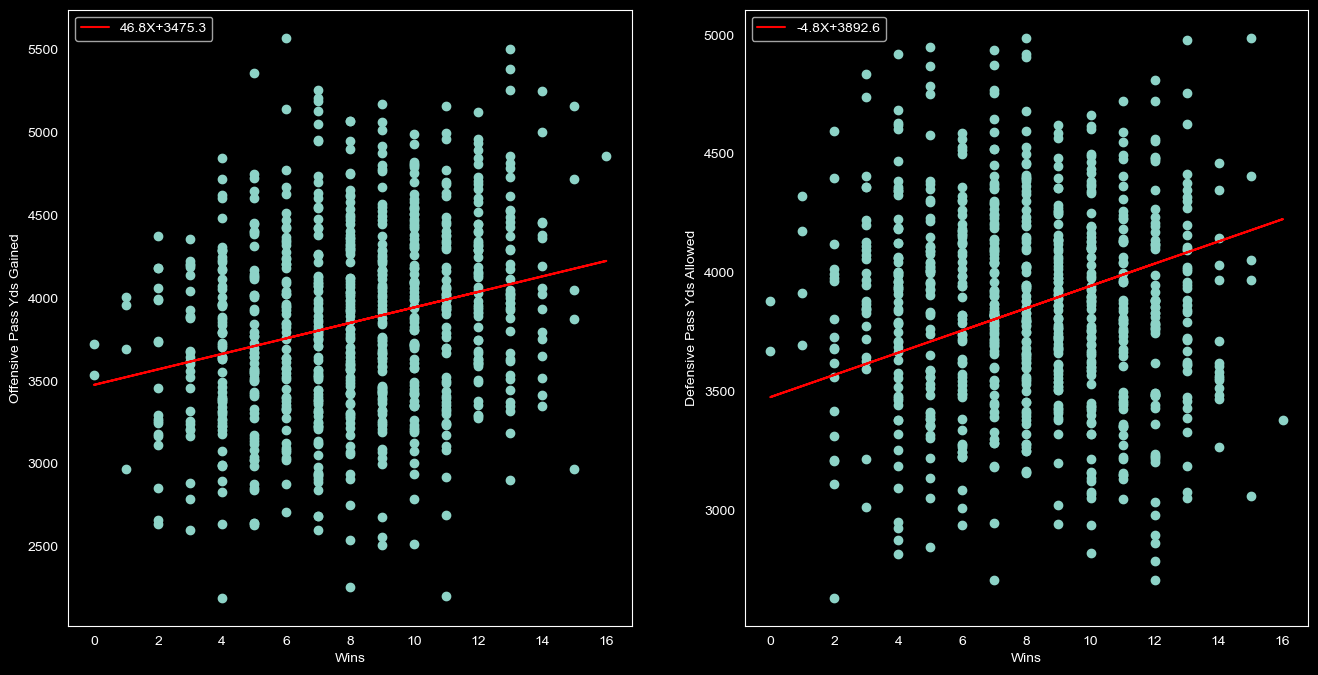

In [20]:
o_pass_yards = srd.stats(offense, 'W', 'Pass Yds')
d_pass_yards = srd.stats(defense, 'W', 'Yds')

o_best_fit = s.linregress(o_pass_yards[0], o_pass_yards[1])
y_o = o_best_fit.intercept + o_best_fit.slope * o_pass_yards[0]

d_best_fit = s.linregress(d_pass_yards[0], d_pass_yards[1])
y_d = d_best_fit.intercept + d_best_fit.slope * d_pass_yards[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8))
ax1.scatter(o_pass_yards[0], o_pass_yards[1])
ax1.plot(o_pass_yards[0], y_o, color = 'red', label = f"{o_best_fit.slope:.1f}X+{o_best_fit.intercept:.1f}")

ax2.scatter(d_pass_yards[0], d_pass_yards[1])
ax2.plot(d_pass_yards[0], y_o, color = 'red', label = f"{d_best_fit.slope:.1f}X+{d_best_fit.intercept:.1f}")

ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

ax1.grid(False)
ax2.grid(False)

ax1.set_ylabel('Offensive Pass Yds Gained')
ax2.set_ylabel('Defensive Pass Yds Allowed')
ax1.set_xlabel('Wins')
ax2.set_xlabel('Wins')

plt.show()